In [1]:
import sys, os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# import pickle as pk
import numpy as np
import torch
dev = torch.device("mps")
import torch.optim as optim
# from torch.distributions import MultivariateNormal
# from torch.distributions import Normal
# root_dir = '/mnt/home/spandey/ceph/AR_NPE/'
# os.chdir(root_dir)
# import colossus
import sys, os
# append the root_dir to the path
# sys.path.append(root_dir)
# from nf.combined_models_wmaskSumGauss import COMBINED_Model
# from nf.combined_models_classification import COMBINED_Model
# from nf.all_models import *
# from nf.utils_data_prep_cosmo import *
# from tqdm import tqdm
# import pyyaml
from colossus.cosmology import cosmology
params = {'flat': True, 'H0': 67.11, 'Om0': 0.3175, 'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624}
cosmo = cosmology.setCosmology('myCosmo', **params)
# get halo mass function:
from colossus.lss import mass_function
from tqdm import tqdm
    
import yaml
import pickle as pk
# autoreload modules
%load_ext autoreload
%autoreload 2

import matplotlib
%matplotlib inline
import matplotlib.pyplot as pl
import numpy as np
import sys,os
# import readgadget
# import MAS_library as MASL
import pickle as pk
# import readfof
import matplotlib

import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline



# %load_ext Cython


        
        
        



In [2]:
from sklearn.datasets import make_moons
x_moon, y_moon = make_moons(n_samples=500000, noise=0.01, random_state=None)

# pl.figure()
# pl.scatter(x_moon[:,0], x_moon[:,1], s=0.1)



In [3]:
# scale each dimension to [0,1]:
data_scaled = np.zeros_like(x_moon)
ndim_data = x_moon.shape[1]
min_data_all = np.zeros(ndim_data)
max_data_all = np.zeros(ndim_data)
fac_scale = 1.1
for i in range(ndim_data):
    data_scaled[:,i] = (x_moon[:,i]-fac_scale*np.min(x_moon[:,i]))/(fac_scale*(np.max(x_moon[:,i])-np.min(x_moon[:,i])))
    min_data_all[i] = fac_scale*np.min(x_moon[:,i])
    max_data_all[i] = fac_scale*np.max(x_moon[:,i])


(0.0, 1.0)

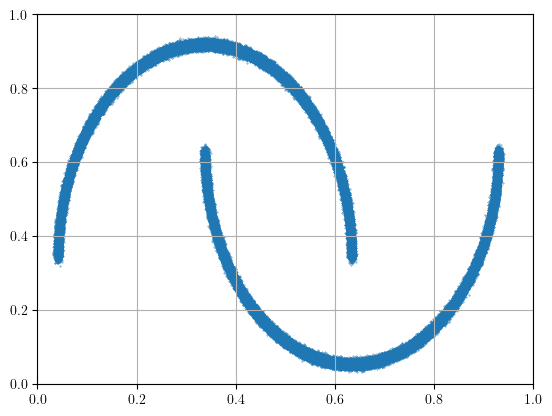

In [4]:
pl.figure()
pl.scatter(data_scaled[:,0], data_scaled[:,1], s=0.1)
pl.grid()
pl.xlim(0,1)
pl.ylim(0,1)


In [37]:
nvocab = 1024
bins_digitize = np.linspace(-1e-3, 1, nvocab)
data_digitized = np.digitize(data_scaled, bins_digitize)




In [38]:
# prepend 0 to first axis for all data:
start_token = 0
data_digitized = np.concatenate([start_token + np.zeros((data_digitized.shape[0], 1)), data_digitized], axis=1)




In [39]:
n = int(0.8*len(data_digitized)) # first 90% will be train, rest val
train_data = data_digitized[:n]
val_data = data_digitized[n:]



In [40]:
train_data.shape

(400000, 3)

In [41]:
device = 'cuda'

x = torch.tensor(train_data[:, :-1]).long()
y = torch.tensor(train_data[:, 1:]).long()
x, y = torch.tensor(x).to(device), torch.tensor(y).to(device)
x_train = x.long()
y_train = y.long()

x = torch.tensor(val_data[:, :-1]).long()
y = torch.tensor(val_data[:, 1:]).long()

x, y = torch.tensor(x).to(device), torch.tensor(y).to(device)
x_val = x.long()
y_val = y.long()



/tmp/ipykernel_1599721/3545606205.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x, y = torch.tensor(x).to(device), torch.tensor(y).to(device)
/tmp/ipykernel_1599721/3545606205.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x, y = torch.tensor(x).to(device), torch.tensor(y).to(device)


In [42]:
# x_train.shape, y_train.shape

In [48]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
# batch_size = 16 # how many independent sequences will we process in parallel?
# block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 10
learning_rate = 1e-3
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 32
n_head = 4
n_layer = 4
dropout = 0.2
# ------------
vocab_size = nvocab + 1
block_size = ndim_data
batch_size = 65536*4



In [49]:
def get_batch(split, batch_size=None):
    if split == 'train':
        x = x_train
        y = y_train
        # mask = mask_train
    elif split == 'val':
        x = x_val
        y = y_val
        # mask = mask_val
    if batch_size is not None:
        x = x[:batch_size]
        y = y[:batch_size]
        # mask = mask[:batch_size]
    return x, y
    # return x, y

class mySequential(nn.Sequential):
    def forward(self, *inputs):
        for module in self._modules.values():
            if type(inputs) == tuple:
                inputs = module(*inputs)
            else:
                inputs = module(inputs)
        return inputs

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = x
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        if mask is not None:
            wei += mask
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        out = torch.cat([h(x, mask) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x, mask):
        x = x + self.sa(self.ln1(x), mask)
        x = x + self.ffwd(self.ln2(x))
        return x
    
# super simple bigram model
class HaloDecoderModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        # self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.blocks = nn.ModuleList([Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        # self.blocks = mySequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None, mask=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        # x = self.blocks(x) # (B,T,C)
        # x = self.blocks((x,mask)) # (B,T,C)        
        for block in self.blocks:
            x = block(x, mask)
        
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)

            loss = F.cross_entropy(logits, targets, ignore_index=1)

        return logits, loss

    def generate(self, idx_inp, max_new_tokens, nvox_samp=32):
        # idx is (B, T) array of indices in the current context
        idx_all = []
        for jv in range(nvox_samp):
            idx = idx_inp
            for _ in range(max_new_tokens):
                # crop idx to the last block_size tokens
                idx_cond = idx[:, -block_size:]
                # get the predictions
                logits, loss = self(idx_cond)
                # focus only on the last time step
                logits = logits[:, -1, :] # becomes (B, C)
                # apply softmax to get probabilities
                probs = F.softmax(logits, dim=-1) # (B, C)
                # sample from the distribution
                idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
                # append sampled index to the running sequence
                # if idx_next == end_token:
                    # break
                idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
            idx_all.append(idx)
        return idx_all





In [50]:
model = HaloDecoderModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)



0.117185 M parameters


In [51]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, batch_size)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out




In [59]:
val_loss_min = 1e20
# saved = {}
for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        # save the model if it's better than the previous best:
        if losses['val'] < val_loss_min:
            val_loss_min = losses['val']
            torch.save(model.state_dict(), 'model.pt')
            print(f"New best model saved with loss {val_loss_min:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train', batch_size)

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()




step 0: train loss 5.3897, val loss 5.4092
New best model saved with loss 5.4092
step 10: train loss 5.3884, val loss 5.4082
New best model saved with loss 5.4082
step 20: train loss 5.3868, val loss 5.4068
New best model saved with loss 5.4068
step 30: train loss 5.3857, val loss 5.4058
New best model saved with loss 5.4058
step 40: train loss 5.3848, val loss 5.4054
New best model saved with loss 5.4054
step 50: train loss 5.3836, val loss 5.4043
New best model saved with loss 5.4043
step 60: train loss 5.3824, val loss 5.4033
New best model saved with loss 5.4033
step 70: train loss 5.3815, val loss 5.4027
New best model saved with loss 5.4027
step 80: train loss 5.3807, val loss 5.4021
New best model saved with loss 5.4021
step 90: train loss 5.3800, val loss 5.4016
New best model saved with loss 5.4016
step 100: train loss 5.3792, val loss 5.4012
New best model saved with loss 5.4012
step 110: train loss 5.3785, val loss 5.4006
New best model saved with loss 5.4006
step 120: train

KeyboardInterrupt: 

In [60]:
nvox_samp = 16384
idx_inp = torch.zeros((nvox_samp, 1), dtype=torch.long, device=device)

max_new_tokens = 2
# idx_all = []
# for jv in range(nvox_samp):
idx = idx_inp
for _ in range(max_new_tokens):
    # crop idx to the last block_size tokens
    idx_cond = idx[:, -block_size:]
    # get the predictions
    logits, loss = m(idx_cond)
    # focus only on the last time step
    logits = logits[:, -1, :] # becomes (B, C)
    # apply softmax to get probabilities
    probs = F.softmax(logits, dim=-1) # (B, C)
    # sample from the distribution
    idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
    # append sampled index to the running sequence
    # if idx_next == end_token:
        # break
    idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
# idx_all.append(idx.detach().cpu().numpy())
    

In [61]:
idx.shape


torch.Size([16384, 3])

In [62]:
# np.array(idx_all).shape
# idx_out = np.array(idx_all)[:,0,1:]
idx_out = (idx.detach().cpu().numpy())[:,1:]
idx_out.shape


(16384, 2)

In [63]:
data_set_out_detokenized = np.zeros(idx_out.shape)
for i in range(ndim_data):
    data_set_out_detokenized[:,i] = bins_digitize[idx_out[:,i]]



In [64]:
y_detokenized = np.zeros(y_val.shape)
for i in range(ndim_data):
    y_detokenized[:,i] = bins_digitize[y_val[:,i].detach().cpu().numpy()]



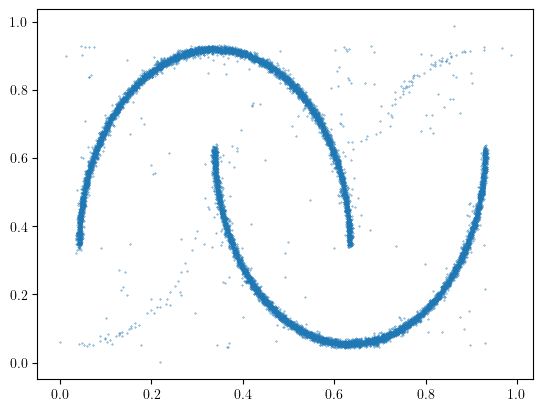

In [65]:
pl.figure()
pl.scatter(data_set_out_detokenized[:,0], data_set_out_detokenized[:,1], s=0.1)


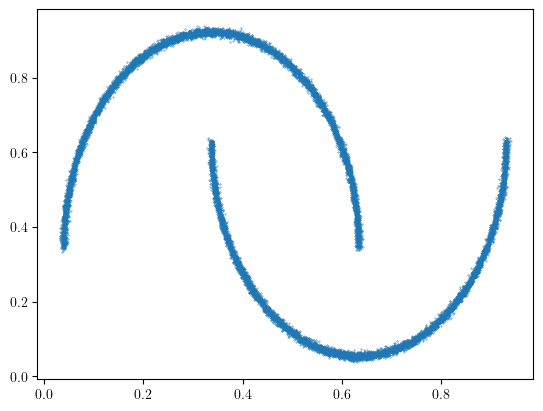

In [104]:
pl.figure()
pl.scatter(y_detokenized[:,0], y_detokenized[:,1], s=0.1)


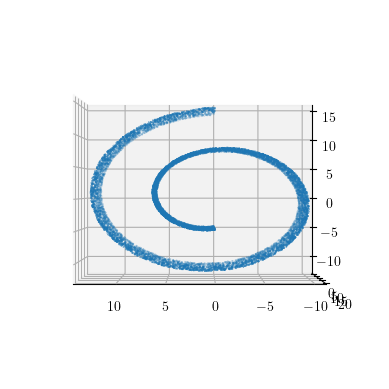

In [5]:
from sklearn.datasets import make_swiss_roll
X, t = make_swiss_roll(n_samples=10000, noise=0.01, random_state=0)

# pl.figure()
# pl.scatter(X[:,0], X[:,1], c=t, s=0.1)
fig = pl.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], s=0.1)
ax.view_init(0,90,0)
